In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Asus Vivobook\OneDrive\Desktop\ML\Lab_ML\Ass-2\Loan\train.csv")

In [5]:

df.head()
df.info()
df.describe()
df.columns
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer ID                  30000 non-null  object 
 1   Name                         30000 non-null  object 
 2   Gender                       29947 non-null  object 
 3   Age                          30000 non-null  int64  
 4   Income (USD)                 25424 non-null  float64
 5   Income Stability             28317 non-null  object 
 6   Profession                   30000 non-null  object 
 7   Type of Employment           22730 non-null  object 
 8   Location                     30000 non-null  object 
 9   Loan Amount Request (USD)    30000 non-null  float64
 10  Current Loan Expenses (USD)  29828 non-null  float64
 11  Expense Type 1               30000 non-null  object 
 12  Expense Type 2               30000 non-null  object 
 13  Dependents      

(30000, 24)

In [6]:
df.columns

Index(['Customer ID', 'Name', 'Gender', 'Age', 'Income (USD)',
       'Income Stability', 'Profession', 'Type of Employment', 'Location',
       'Loan Amount Request (USD)', 'Current Loan Expenses (USD)',
       'Expense Type 1', 'Expense Type 2', 'Dependents', 'Credit Score',
       'No. of Defaults', 'Has Active Credit Card', 'Property ID',
       'Property Age', 'Property Type', 'Property Location', 'Co-Applicant',
       'Property Price', 'Loan Sanction Amount (USD)'],
      dtype='object')

In [10]:
# numeric columns
num_cols = df.select_dtypes(
include=['int64', 'float64']
).columns.tolist()

binary_cols = [col for col in df.columns if df[col].nunique() == 2]
# categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()

In [12]:
print(num_cols)
print(cat_cols)
print(binary_cols)

['Age', 'Income (USD)', 'Loan Amount Request (USD)', 'Current Loan Expenses (USD)', 'Dependents', 'Credit Score', 'No. of Defaults', 'Property ID', 'Property Age', 'Property Type', 'Co-Applicant', 'Property Price', 'Loan Sanction Amount (USD)']
['Customer ID', 'Name', 'Gender', 'Income Stability', 'Profession', 'Type of Employment', 'Location', 'Expense Type 1', 'Expense Type 2', 'Has Active Credit Card', 'Property Location']
['Gender', 'Income Stability', 'Expense Type 1', 'Expense Type 2', 'No. of Defaults']


In [9]:
df.isnull().sum()

Customer ID                       0
Name                              0
Gender                           53
Age                               0
Income (USD)                   4576
Income Stability               1683
Profession                        0
Type of Employment             7270
Location                          0
Loan Amount Request (USD)         0
Current Loan Expenses (USD)     172
Expense Type 1                    0
Expense Type 2                    0
Dependents                     2493
Credit Score                   1703
No. of Defaults                   0
Has Active Credit Card         1566
Property ID                       0
Property Age                   4850
Property Type                     0
Property Location               356
Co-Applicant                      0
Property Price                    0
Loan Sanction Amount (USD)      340
dtype: int64

In [16]:
for i in cat_cols:
    df[i].fillna(value=df[i].mode()[0], inplace=True)


C:\Users\Asus Vivobook\AppData\Local\Temp\ipykernel_2312\3674465337.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(value=df[i].mode()[0], inplace=True)


In [18]:
for i in num_cols:
    df[i].fillna(value=df[i].median(), inplace=True)


C:\Users\Asus Vivobook\AppData\Local\Temp\ipykernel_2312\1016842917.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(value=df[i].median(), inplace=True)
C:\Users\Asus Vivobook\AppData\Local\Temp\ipykernel_2312\1016842917.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

In [19]:
df.isnull().sum()

Customer ID                    0
Name                           0
Gender                         0
Age                            0
Income (USD)                   0
Income Stability               0
Profession                     0
Type of Employment             0
Location                       0
Loan Amount Request (USD)      0
Current Loan Expenses (USD)    0
Expense Type 1                 0
Expense Type 2                 0
Dependents                     0
Credit Score                   0
No. of Defaults                0
Has Active Credit Card         0
Property ID                    0
Property Age                   0
Property Type                  0
Property Location              0
Co-Applicant                   0
Property Price                 0
Loan Sanction Amount (USD)     0
dtype: int64

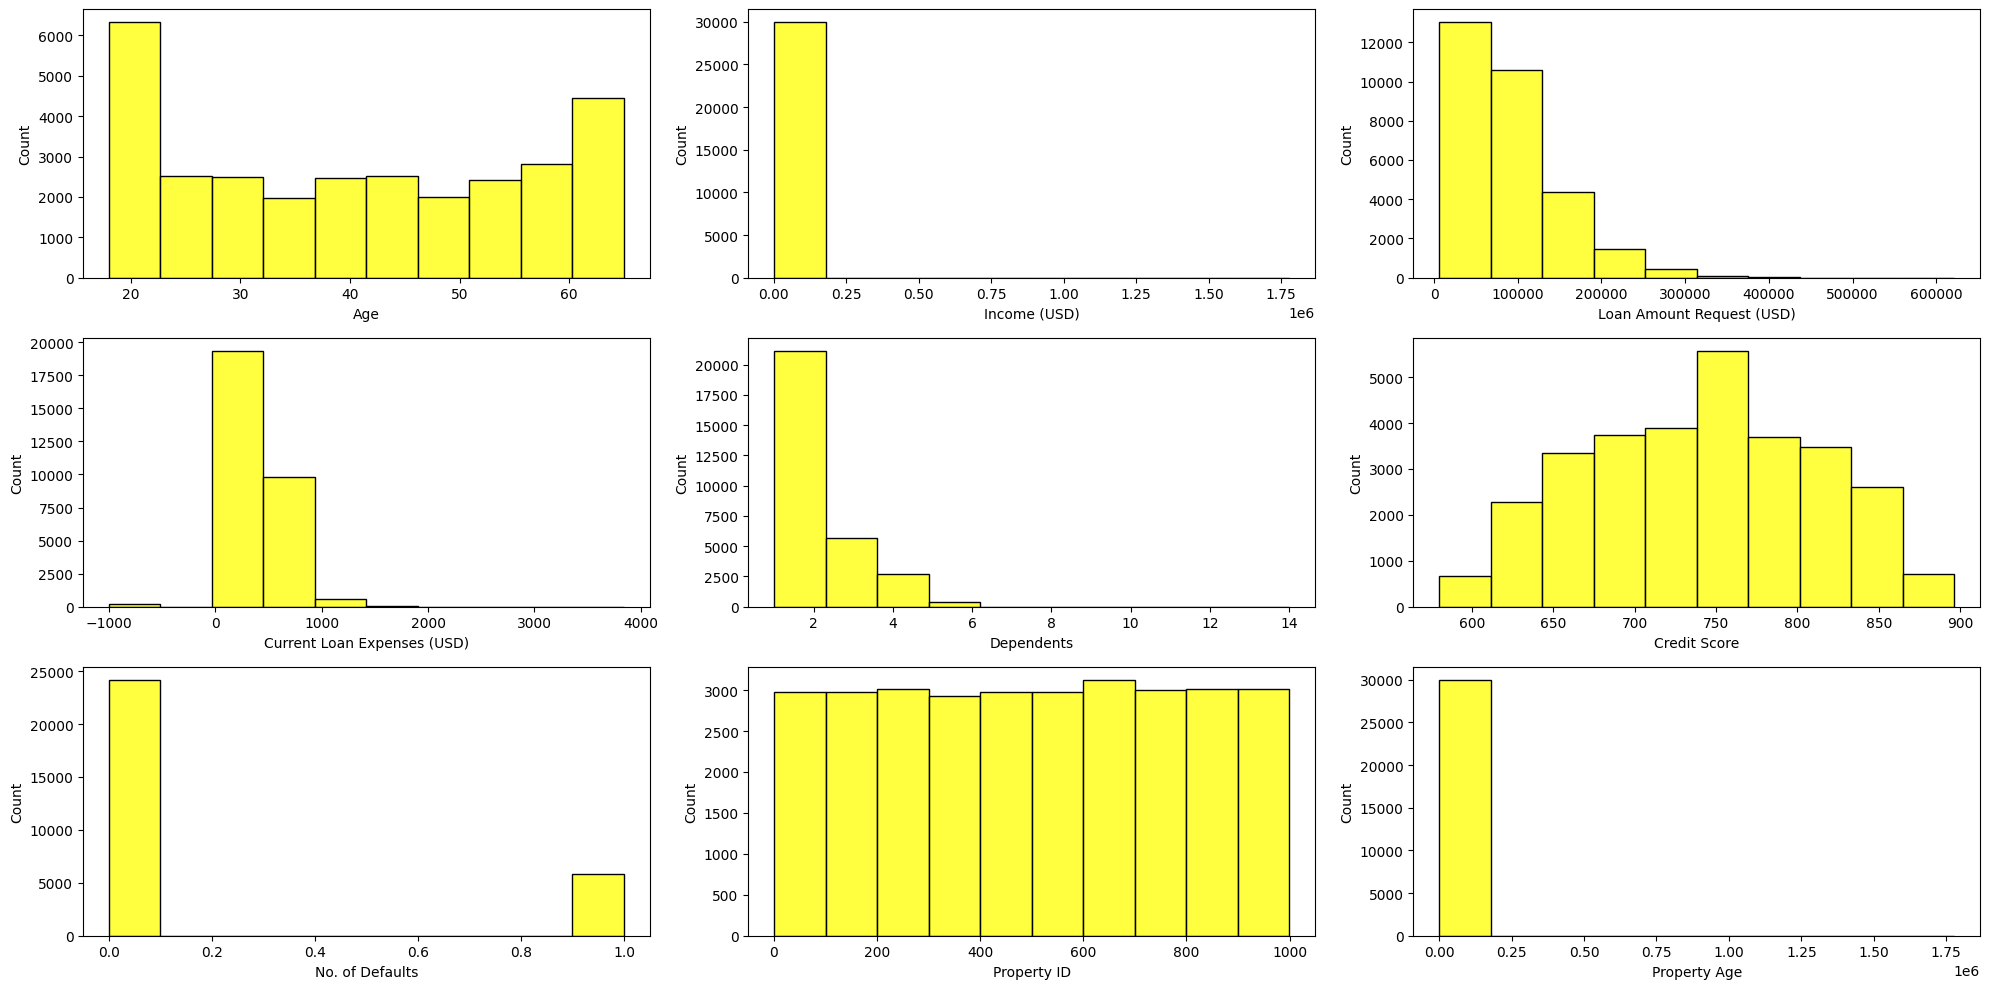

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(
nrows=3, ncols=3,
figsize=(20,10)
)

axes=axes.flatten()
count=0
for i in num_cols:
    sns.histplot(
    data=df,
    x=i,
    bins=10,
    color="yellow", # optional
    edgecolor="black", # optional
    ax=axes[count]
    )

    count+=1
    if count==len(axes):
        break

plt.tight_layout()
plt.show()

<Axes: >

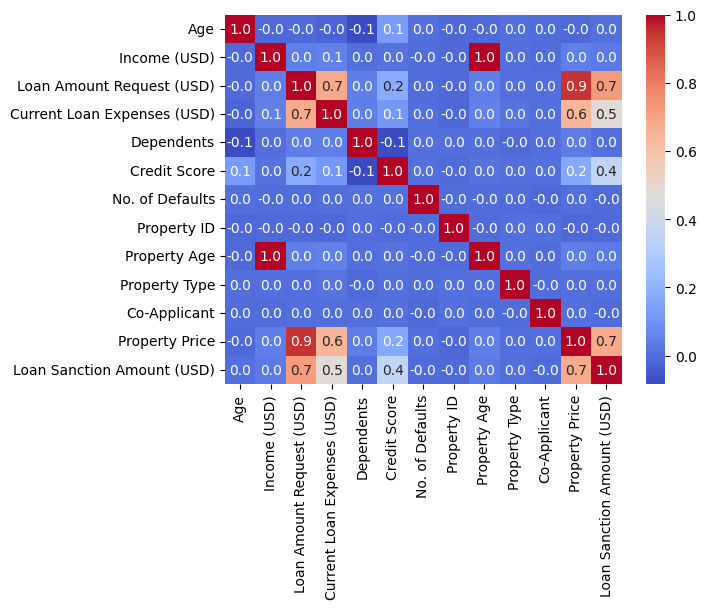

In [24]:
corr=df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".1f",
cmap="coolwarm")

In [25]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import MaxAbsScaler, RobustScaler

df[num_cols] = StandardScaler().fit_transform(df[num_cols])

In [28]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder

for i in cat_cols:
    df[i] = LabelEncoder().fit_transform(df[i])

In [30]:
df.columns

Index(['Customer ID', 'Name', 'Gender', 'Age', 'Income (USD)',
       'Income Stability', 'Profession', 'Type of Employment', 'Location',
       'Loan Amount Request (USD)', 'Current Loan Expenses (USD)',
       'Expense Type 1', 'Expense Type 2', 'Dependents', 'Credit Score',
       'No. of Defaults', 'Has Active Credit Card', 'Property ID',
       'Property Age', 'Property Type', 'Property Location', 'Co-Applicant',
       'Property Price', 'Loan Sanction Amount (USD)'],
      dtype='object')

In [32]:
df.drop(columns=['Customer ID','Name'],inplace=True)

In [33]:
x=df.drop(columns=['Loan Sanction Amount (USD)'],inplace=False)

In [34]:
y=df['Loan Sanction Amount (USD)']

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
x, y, test_size=0.3, random_state=42
)

In [37]:
from sklearn.decomposition import PCA
pca = PCA(
n_components=2, # e.g., 0.95 or 2
random_state=42
)

In [38]:
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [40]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso,LogisticRegression
rid=Ridge(alpha=1.0)


In [41]:
rid.fit(X_train_pca,y_train)

Ridge()

In [42]:
y_pred=rid.predict(X_test_pca)

In [45]:
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error

r2=r2_score(y_test, y_pred)
msr=mean_squared_error(y_test, y_pred)
mae=mean_absolute_error(y_test, y_pred)

In [46]:
print(r2)
print(msr)
print(mae)

0.0215666934946116
0.9612762550367996
0.774051173632998


In [49]:
from sklearn.model_selection import KFold, cross_val_score, cross_validate,StratifiedKFold
kf=KFold(n_splits=5, shuffle=True, random_state=42)

In [51]:
score=cross_val_score(estimator=Ridge(alpha=1.0),
X=X_train_pca, y=y_train,
cv=kf, scoring="r2")

In [52]:
score

array([0.02350215, 0.02230805, 0.01297801, 0.01505572, 0.02037095])